In [56]:
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [42]:
#Downloaing the dataset:
df = pd.read_excel("receipts.xlsx")  
df.head()


,Paid Amount,is delivery,is_morning,is_afternoon,is_evening,ratio_kebab,ratio_combo,ratio_drink,ratio_other
0,182.0,0,1,0,0,0.851648,0.0,0.148352,0.000000
1,691.0,0,1,0,0,0.821997,0.0,0.053546,0.124457
2,142.0,0,1,0,0,1.000000,0.0,0.000000,0.000000
3,273.0,1,1,0,0,1.000000,0.0,0.000000,0.000000
4,438.0,1,1,0,0,0.785388,0.0,0.214612,0.000000


In [43]:
# Define the numeric columns to scale
numeric_cols = [
    "Paid Amount",
    "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
]

# Define the feature set for experiment
feature_sets = {
    "set": [
         "Paid Amount", "is delivery",
    "is_morning", "is_afternoon", "is_evening",
    "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
    ]
}

# Function to scale numeric columns
def scale_numeric_columns(df, numeric_cols):
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df

df_scaled = scale_numeric_columns(df.copy(), numeric_cols)
X = df_scaled[feature_set]


Running clustering for set...


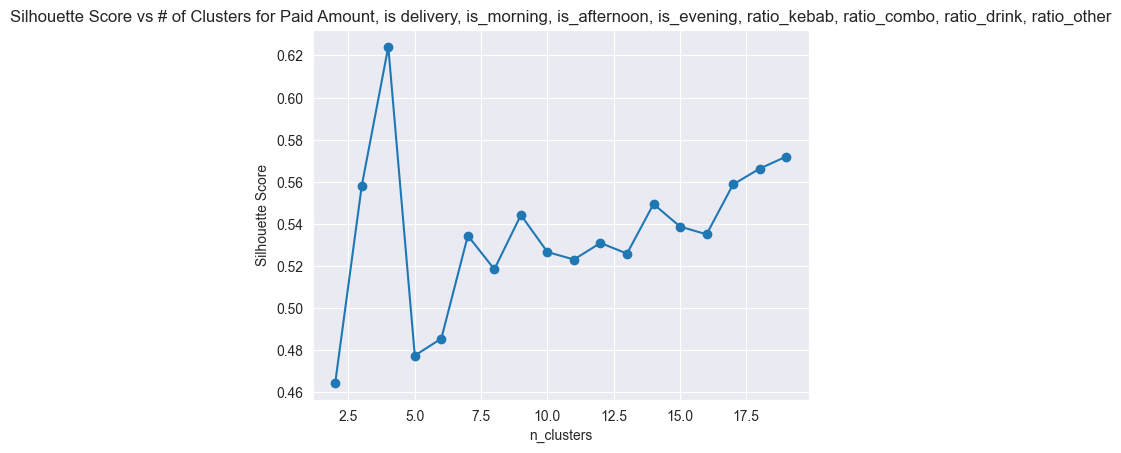

→ Best n_clusters for Paid Amount, is delivery, is_morning, is_afternoon, is_evening, ratio_kebab, ratio_combo, ratio_drink, ratio_other = 4
Best silhouette score: 0.6241314491930278


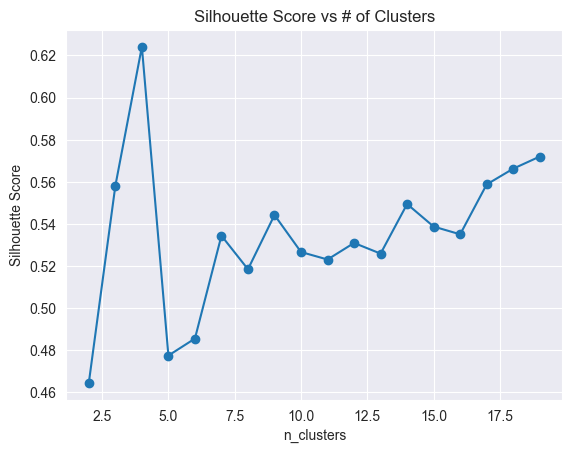

In [44]:
# Function to perform clustering and silhouette analysis
def perform_clustering(df, feature_set, numeric_cols):
    
    sil_scores = []
    K_range = range(2, 20)
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        sil_scores.append(silhouette_score(X, labels))

    plt.plot(K_range, sil_scores, marker="o")
    plt.title(f"Silhouette Score vs # of Clusters for {', '.join(feature_set)}")
    plt.xlabel("n_clusters")
    plt.ylabel("Silhouette Score")
    plt.show()

    best_k = K_range[sil_scores.index(max(sil_scores))]
    print(f"→ Best n_clusters for {', '.join(feature_set)} = {best_k}")
    return best_k, sil_scores


for set_name, feature_set in feature_sets.items():
    print(f"\nRunning clustering for {set_name}...")
    best_k, sil_scores = perform_clustering(df, feature_set, numeric_cols)
    print(f"Best silhouette score: {max(sil_scores)}")
    plt.plot(range(2, 20), sil_scores, marker="o")
    plt.title(f"Silhouette Score vs # of Clusters")
    plt.xlabel("n_clusters")
    plt.ylabel("Silhouette Score")
    plt.show()




Running Calinski-Harabasz evaluation...


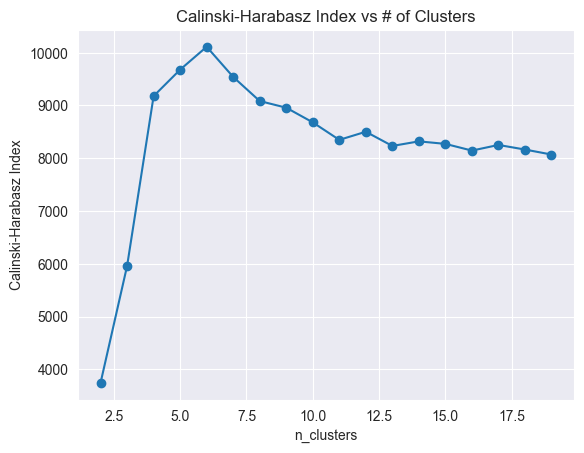

→ Best n_clusters for Paid Amount, is delivery, is_morning, is_afternoon, is_evening, ratio_kebab, ratio_combo, ratio_drink, ratio_other = 6
→ Best Calinski-Harabasz Index for Paid Amount, is delivery, is_morning, is_afternoon, is_evening, ratio_kebab, ratio_combo, ratio_drink, ratio_other = 10111.734408339682
Best Calinski-Harabasz Index: 10111.734408339682


In [45]:
# Calinski-Harabasz Index
def evaluate_calinski_harabasz(df, feature_set, numeric_cols):
    
    K_range = range(2, 20)
    ch_scores = []

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        ch_score = calinski_harabasz_score(X, labels)
        ch_scores.append(ch_score)

    plt.plot(K_range, ch_scores, marker="o")
    plt.title(f"Calinski-Harabasz Index vs # of Clusters")
    plt.xlabel("n_clusters")
    plt.ylabel("Calinski-Harabasz Index")
    plt.show()

    best_k = K_range[ch_scores.index(max(ch_scores))]
    print(f"→ Best n_clusters for {', '.join(feature_set)} = {best_k}")
    print(f"→ Best Calinski-Harabasz Index for {', '.join(feature_set)} = {max(ch_scores)}")
    return best_k, ch_scores

for set_name, feature_set in feature_sets.items():
    print(f"\nRunning Calinski-Harabasz evaluation...")
    best_k, ch_scores = evaluate_calinski_harabasz(df, feature_set, numeric_cols)
    print(f"Best Calinski-Harabasz Index: {max(ch_scores)}")

In [46]:
# Fit K-Means with k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

ch_index = calinski_harabasz_score(X, labels)
print(f"Calinski–Harabasz Index for k={k}: {ch_index:.2f}")


Calinski–Harabasz Index for k=4: 9177.67


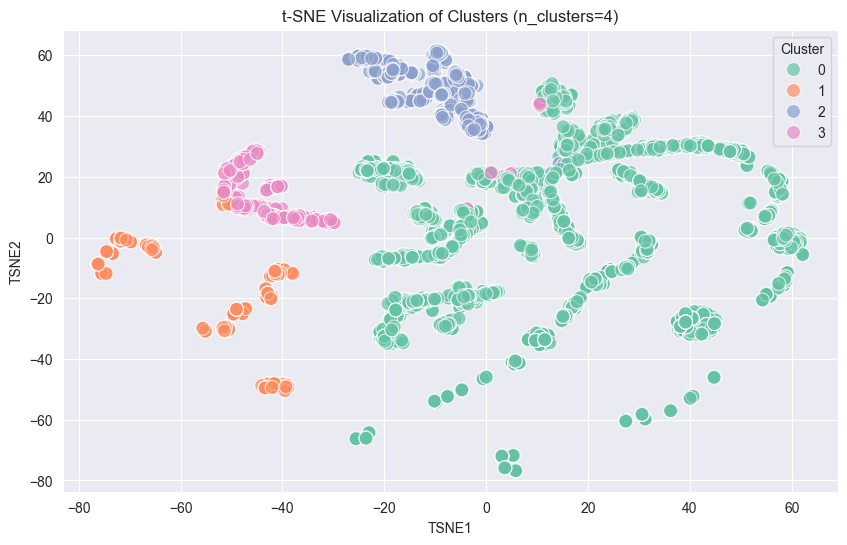

Cluster feature statistics (mean, min, max, median):
        Paid Amount                                is delivery                 \
               mean       min        max    median        mean min max median   
Cluster                                                                         
0          0.118722 -0.635336   7.083801 -0.234077    0.063841   0   1    0.0   
1         -1.236211 -1.369844  -0.145664 -1.301834    0.000000   0   0    0.0   
2          0.951333 -0.465311  10.191859  0.575242    0.297138   0   1    0.0   
3         -0.684718 -1.519467   2.737961 -0.900575    0.035632   0   1    0.0   

        is_morning      ... ratio_combo          ratio_drink            \
              mean min  ...         max   median        mean       min   
Cluster                 ...                                              
0         0.101220   0  ...    0.697709 -0.34189   -0.318679 -0.473062   
1         0.155932   0  ...   -0.341890 -0.34189    2.789718  1.277416   
2        

In [47]:
# t-SNE Visualization of Clusters
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(df_scaled)

df_scaled['Cluster'] = labels

tsne = TSNE(n_components=2, random_state=42, perplexity=150)
df_tsne = tsne.fit_transform(df_scaled[feature_set])

df_tsne_df = pd.DataFrame(df_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne_df['Cluster'] = labels

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tsne_df, x='TSNE1', y='TSNE2', hue='Cluster', palette='Set2', s=100, alpha=0.7)
plt.title("t-SNE Visualization of Clusters (n_clusters=4)")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.legend(title="Cluster")
plt.show()

cluster_stats = df_scaled.groupby('Cluster').agg(['mean', 'min', 'max', 'median'])

print("Cluster feature statistics (mean, min, max, median):")
print(cluster_stats)


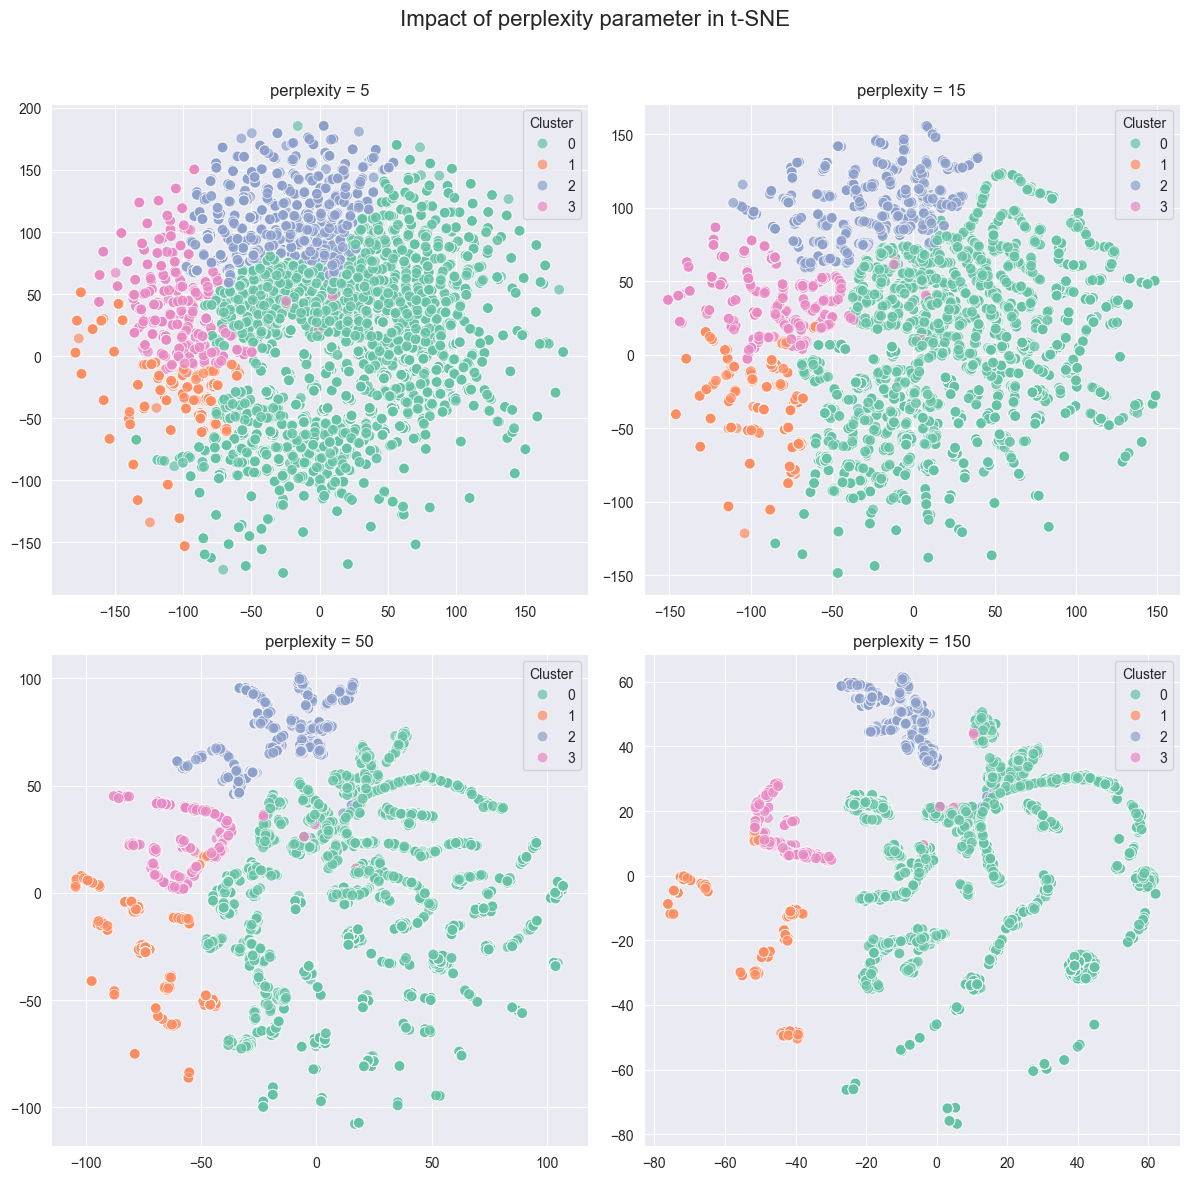

In [48]:
# list of perplexities to brute-force
perplexities = [5, 15, 50, 150]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    tsne_proj = tsne.fit_transform(df_scaled[feature_set])
    
    df_tsne = pd.DataFrame(tsne_proj, columns=['TSNE1', 'TSNE2'])
    df_tsne['Cluster'] = df_scaled['Cluster']
    
    sns.scatterplot(
        data=df_tsne,
        x='TSNE1', y='TSNE2',
        hue='Cluster',
        palette='Set2',
        s=60, alpha=0.7,
        ax=ax
    )
    ax.set_title(f'perplexity = {perp}')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(title='Cluster', loc='best')

fig.suptitle('Impact of perplexity parameter in t-SNE', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [49]:
#reverse scaling and displaying the statistics for each cluster(min, max, median, mean)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled[feature_set])

df_scaled['Cluster'] = labels

def reverse_scaling(df_scaled, numeric_cols, scaler):
    df_rescaled = df_scaled.copy()
    df_rescaled[numeric_cols] = scaler.inverse_transform(df_rescaled[numeric_cols])
    return df_rescaled

df_rescaled = reverse_scaling(df_scaled, numeric_cols, scaler)


cluster_stats_rescaled = df_rescaled.groupby('Cluster').agg(['mean', 'min', 'max', 'median'])

print("Cluster feature statistics (mean, min, max, median) on original scale:")
print(cluster_stats_rescaled)


Cluster feature statistics (mean, min, max, median) on original scale:
        Paid Amount                       is delivery                 \
               mean    min     max median        mean min max median   
Cluster                                                                
0        245.874574  135.0  1270.0  194.0    0.063841   0   1    0.0   
1         46.649153   27.0   207.0   37.0    0.000000   0   0    0.0   
2        368.299285  160.0  1727.0  313.0    0.297138   0   1    0.0   
3        127.739080    5.0   631.0   96.0    0.035632   0   1    0.0   

        is_morning      ... ratio_combo           ratio_drink            \
              mean min  ...         max    median        mean       min   
Cluster                 ...                                               
0         0.101220   0  ...     0.29304  0.000000    0.047037  0.000000   
1         0.155932   0  ...     0.00000  0.000000    0.994099  0.533333   
2         0.098485   0  ...     1.00000  0.936397


===== Running full metric suite for set =====

── Davies–Bouldin


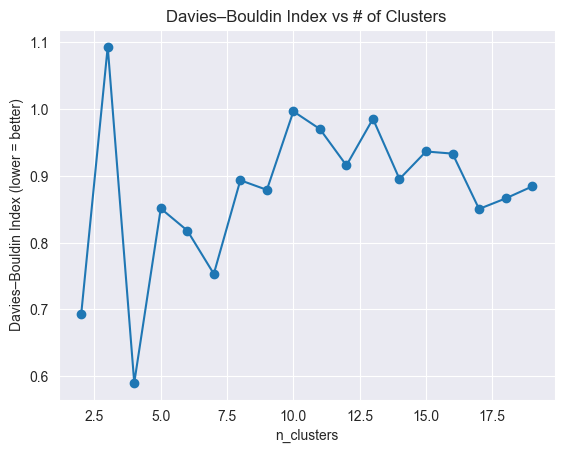

→ Best n_clusters (lowest DBI) = 4
→ Best Davies–Bouldin Index = 0.5903

── Elbow / Inertia


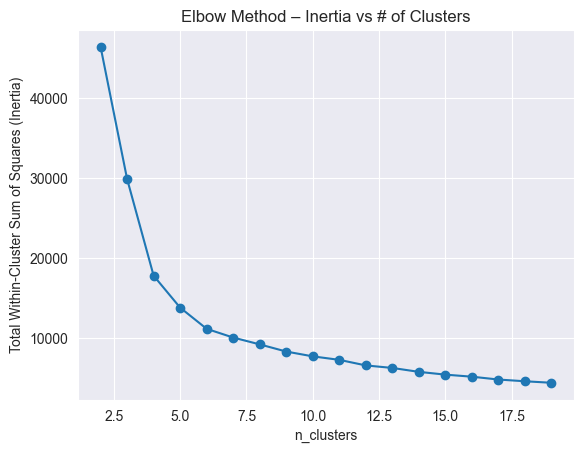


Summary of suggested k values:
  • Davies–Bouldin best k:      4


In [55]:
#Computing metrix: davies_bouldin. And plotting inertia_curve
def scale_numeric_columns(df, numeric_cols):
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df, scaler 

def evaluate_davies_bouldin(df, feature_set, numeric_cols, k_range=range(2, 20)):
    df_scaled, scaler = scale_numeric_columns(df.copy(), numeric_cols)
    X = df_scaled[feature_set]

    dbi_scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        dbi_scores.append(davies_bouldin_score(X, labels))

    plt.plot(k_range, dbi_scores, marker="o")
    plt.title("Davies–Bouldin Index vs # of Clusters")
    plt.xlabel("n_clusters")
    plt.ylabel("Davies–Bouldin Index (lower = better)")
    plt.show()

    best_k = k_range[dbi_scores.index(min(dbi_scores))]
    print(f"→ Best n_clusters (lowest DBI) = {best_k}")
    print(f"→ Best Davies–Bouldin Index = {min(dbi_scores):.4f}")
    
    return best_k, dbi_scores

def plot_elbow_inertia(df, feature_set, numeric_cols, k_range=range(2, 20)):
    df_scaled, scaler = scale_numeric_columns(df.copy(), numeric_cols)
    X = df_scaled[feature_set]

    inertia_vals = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertia_vals.append(kmeans.inertia_)

    plt.plot(k_range, inertia_vals, marker="o")
    plt.title("Elbow Method – Inertia vs # of Clusters")
    plt.xlabel("n_clusters")
    plt.ylabel("Total Within-Cluster Sum of Squares (Inertia)")
    plt.show()

    return inertia_vals

def run_all_cluster_metrics(df, feature_set, numeric_cols, k_range=range(2, 20)):
    print("\n── Davies–Bouldin")
    best_k_dbi, _ = evaluate_davies_bouldin(df, feature_set, numeric_cols, k_range)

    print("\n── Elbow / Inertia")
    inertia_vals = plot_elbow_inertia(df, feature_set, numeric_cols, k_range)

    print("\nSummary of suggested k values:")
    print(f"  • Davies–Bouldin best k:      {best_k_dbi}")
    return {
        "davies_bouldin": best_k_dbi,
        "inertia_curve": inertia_vals,
    }

for set_name, feature_set in feature_sets.items():
    print(f"\n===== Running full metric suite for {set_name} =====")
    run_all_cluster_metrics(df, feature_set, numeric_cols)
